## Mithil Agneya
### 3/1/2026
#### Data analysis and answering questions

#### Importing CSV files and libraries

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("Non-Majors Survey Results - Fall 2024.csv")
df_q1 = pd.read_csv("df_q1.csv")
df_q2 = pd.read_csv("df_q2.csv")
df_q3 = pd.read_csv("df_q3.csv")
df_q4 = pd.read_csv("df_q4.csv")
df_q5 = pd.read_csv("df_q5.csv")

#### Answering Question 1: Which recruitment channel is most effective at reaching students who express a high interest in taking further computing courses?

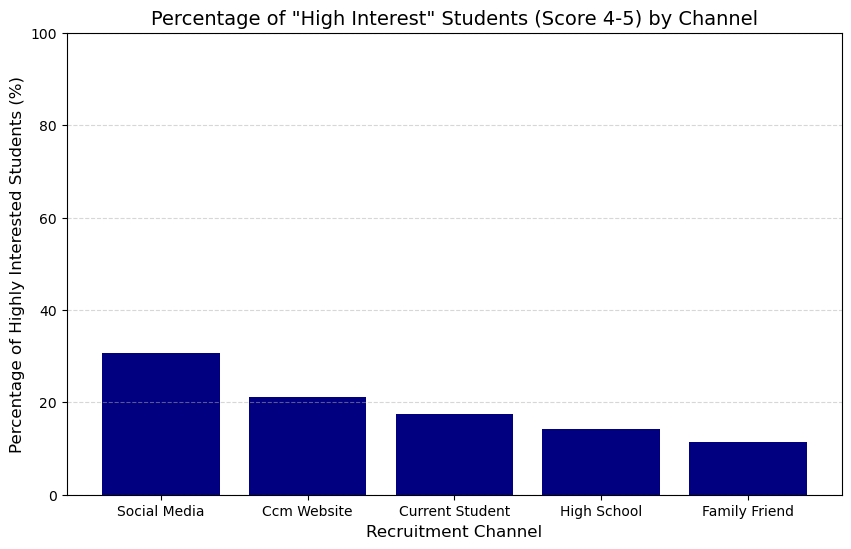

In [55]:
channels = ['heard_ccm_website', 'heard_social_media', 'heard_high_school', 
            'heard_family_friend', 'heard_current_student']

high_interest = {}
for col in channels:
    sub = df_q1[df_q1[col] == 'Yes'] # Subset sourced by AI
    if len(subset) > 0:
        high_sub = subset[subset['interest_more_courses'] >= 4]
    per = (len(high_sub) / len(sub)) * 100

    label = col.replace('heard_', '').replace('_', ' ').title() # Sourced by AI
    high_interest[label] = per


results = pd.Series(high_interest).sort_values(ascending=False) # Sourced by AI

plt.figure(figsize=(10, 6))
plt.bar(results.index, results.values, color='navy')
plt.title('Percentage of "High Interest" Students (Score 4-5) by Channel', fontsize=14)
plt.ylabel('Percentage of Highly Interested Students (%)', fontsize=12)
plt.xlabel('Recruitment Channel', fontsize=12)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

#### Analysis: Based on the bar graph, the Social Media recruitment channel was most effective at reaching students who expressed a high interest in taking further computing courses. Around 30% of students recruited by social media indicated a high interest in taking more classes

#### Answering Question 2: What are the primary motivations for taking a computing class among different degree programs?

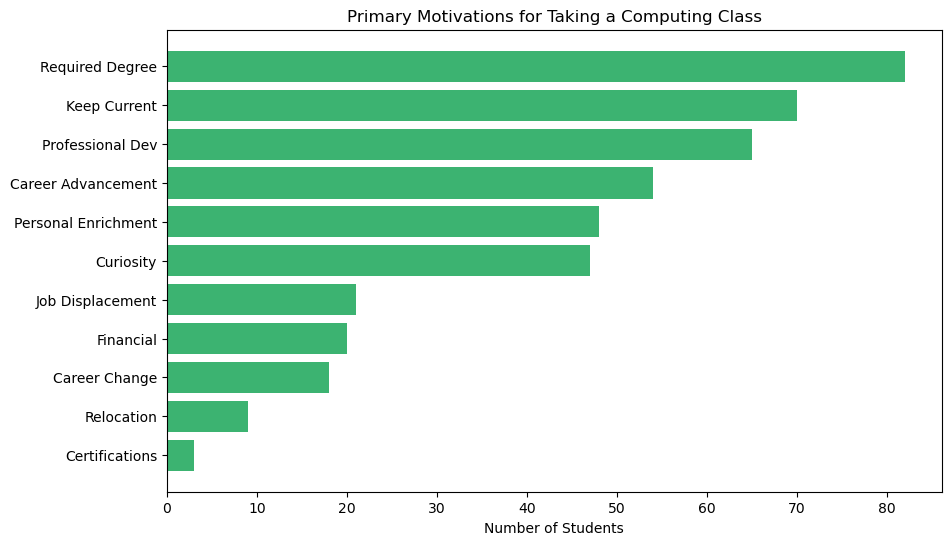

In [42]:
moti_cols = [col for col in df_q2.columns if 'motivation_' in col]

moti_counts = {}
for col in moti_cols:
    count = (df_q2[col] == 'Yes').sum()
    
    clean = col.replace('motivation_', '').replace('_', ' ').title()# Sourced by AI
    moti_counts[clean] = count

results = pd.Series(moti_counts).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(results.index, results.values, color='mediumseagreen')
plt.title('Primary Motivations for Taking a Computing Class')
plt.xlabel('Number of Students')
plt.gca().invert_yaxis() 
plt.show()

#### Analysis: Based on the graph, we can see that the primary motivation for taking a computing class amongst majors apart from computer science is that the course is required for their degree. There are approximately 85 students who replied in this category, with staying up to date and professional development coming in with around 70 and 65 students respectively. 

#### Answering Question 3: Does participation in pre-college outreach programs correlate with higher interest?

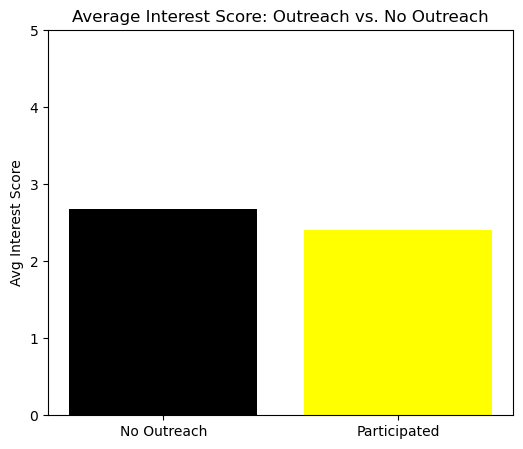

In [50]:
reach_events = []
for col in df_q3:
    if 'prior_event_' in col:
        reach_events.append(col)

df_q3['any_outreach'] = (df_q3[reach_events] == 'Yes').any(axis=1)

comparison = df_q3.groupby('any_outreach')['interest_more_courses'].mean()
 # line of code above splits students by attended outreach or not attended outreach programs and calculates average of the interest column


plt.figure(figsize=(6, 5))
plt.bar(['No Outreach', 'Participated'], comparison.values, color=['black', 'yellow'])
plt.title('Average Interest Score: Outreach vs. No Outreach') 
plt.ylabel('Avg Interest Score')
plt.ylim(0, 5)
plt.show()

#### Analysis: Interestingly, students who did not participate in the listed outreach programs showed a slightly higher interest in future courses than those who did. This suggests outreach may need to be more focused on the computing department specifically 

#### Answering Question 4: Which computing sub-fields are most popular between different age groups?

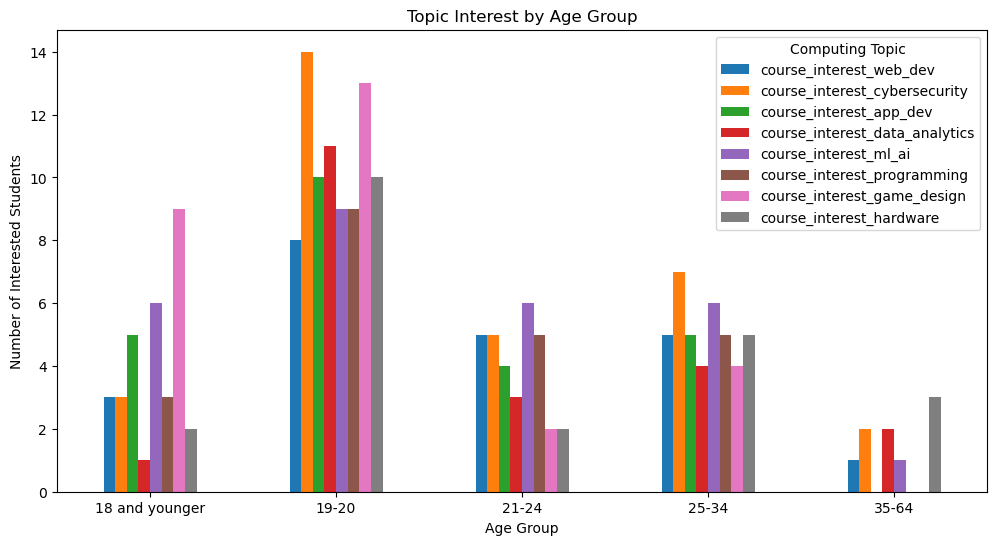

In [52]:
interest_topics = []
for col in df_q4:
    if 'course_interest_' in col:
        interest_topics.append(col)
        
age_trends = df_q4.groupby('age')[interest_topics].apply(lambda x: (x == 'Yes').sum()) # Sourced by AI

age_trends.plot(kind='bar', figsize=(12, 6))
plt.title('Topic Interest by Age Group')
plt.ylabel('Number of Interested Students')
plt.xlabel('Age Group')
plt.xticks(rotation=0)
plt.legend(title='Computing Topic')
plt.show()

#### Analysis: Game Design is overwhelmingly popular with the "18 and younger" group, whereas Cybersecurity remains a strong interest across almost all age categories. This data can help CCM decide which certifications to prioritize for different age demographics.